# VIIRS Nightfire — Gulf States Gas Flares (Oct 2022 – Jun 2023)

Recreating [VNF v4.0](https://eogdata.mines.edu/products/vnf/vnf_v40.html) using FIRMS VIIRS data + Planck curve fitting.

**Output:**
1. Time series — monthly flare count by temperature class (Low < 1000K, Medium 1000–1450K, High > 1450K) + flare volume (BCF)
2. Map — high-temperature signatures (> 1450K) for 1–7 Jun 2023
3. Final GPKG database

In [1]:
import io, time, warnings
from datetime import datetime, timedelta
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#333", "text.color": "#c9d1d9",
    "axes.labelcolor": "#c9d1d9", "xtick.color": "#8b949e",
    "ytick.color": "#8b949e", "figure.dpi": 130, "font.size": 10,
})

# ── Physical constants for Planck fitting ──
_h  = 6.62607015e-34
_c  = 2.99792458e8
_kB = 1.380649e-23
LAM_I4 = 3.74e-6   # VIIRS I4 (MWIR)
LAM_I5 = 11.45e-6  # VIIRS I5 (LWIR)


def _planck(lam, T):
    """Planck radiance B(λ,T) in W/m²/sr/µm (vectorized)."""
    with np.errstate(over="ignore"):
        exp_term = np.exp(_h * _c / (lam * _kB * T))
    return (2 * _h * _c**2 / lam**5) / (exp_term - 1) * 1e-6


def estimate_fire_temperature(T4, T5):
    """
    Vectorized bi-spectral Dozier (1981) method (VNF core).
    T4 = bright_ti4 (K), T5 = bright_ti5 (K) — pixel-integrated brightness temps.
    
    Solves for fire temperature Tf and sub-pixel area fraction p:
      L4_obs = p * B4(Tf) + (1-p) * B4(Tbg)
    where Tbg ≈ T5 (background from LWIR band).
    
    Searches LOW to HIGH to find the minimum valid fire temperature.
    Returns Temp_primary (K), Area_primary (m²).
    """
    T4 = np.asarray(T4, dtype=float)
    T5 = np.asarray(T5, dtype=float)
    
    L4_obs = _planck(LAM_I4, T4)
    L4_bg  = _planck(LAM_I4, T5)
    L4_exc = L4_obs - L4_bg   # excess radiance from fire
    
    Tf = np.full_like(T4, np.nan)
    Af = np.full_like(T4, 0.0)
    
    valid = L4_exc > 0
    
    # Search LOW → HIGH: find minimum valid fire temperature
    # This gives the most physically plausible solution (largest area, lowest temp)
    # Typical gas flares: 1000-2000K; industrial: 600-1200K
    T_candidates = np.linspace(400, 3000, 600)
    
    for T_try in T_candidates:
        B4_try = _planck(LAM_I4, T_try)
        denom = B4_try - L4_bg
        p = np.where(denom > 0, L4_exc / denom, 999.0)
        
        # p must be physically valid: tiny fraction of 375m pixel
        newly_solved = valid & np.isnan(Tf) & (p > 1e-8) & (p < 1.0)
        Tf = np.where(newly_solved, T_try, Tf)
        Af = np.where(newly_solved, p * 375 * 375, Af)
    
    # Fallback: unsolved pixels get T4 as lower-bound estimate
    unsolved = valid & np.isnan(Tf)
    Tf = np.where(unsolved, T4, Tf)
    
    return Tf, Af

print("Engine ready.")

Engine ready.


## 1. Configuration

In [2]:
FIRMS_MAP_KEY = "2b1c34df0e49ece7703e69e48ab89256"
FIRMS_BASE = "https://firms.modaps.eosdis.nasa.gov/api/area/csv"

START_DATE = "2022-10-01"
END_DATE   = "2023-06-07"

# Gulf states bbox (excludes Africa) — covers Persian Gulf region
GULF_BBOX = "44,16,60,36"

COUNTRY_BBOX = {
    "Kuwait":        (46.5, 28.5, 48.5, 30.1),
    "Iraq":          (38.8, 29.0, 48.6, 37.4),
    "Iran":          (44.0, 25.0, 63.3, 39.8),
    "Saudi Arabia":  (34.5, 16.3, 55.7, 32.2),
    "UAE":           (51.5, 22.6, 56.4, 26.1),
    "Qatar":         (50.7, 24.4, 51.7, 26.2),
    "Bahrain":       (50.3, 25.7, 50.8, 26.3),
    "Oman":          (51.8, 16.6, 59.8, 26.4),
    "Yemen":         (42.5, 12.1, 54.5, 19.0),
}

GPKG_PATH = Path("data/gulf_flares_vnf.gpkg")
GPKG_PATH.parent.mkdir(exist_ok=True)

print(f"Period: {START_DATE} to {END_DATE}")
print(f"BBOX:   {GULF_BBOX}")

Period: 2022-10-01 to 2023-06-07
BBOX:   44,16,60,36


## 2. Download VIIRS data (FIRMS API)

In [3]:
# Load pre-downloaded data (run run_download.py first if parquet doesn't exist)
RAW_PATH = Path("data/raw_gulf_oct22_oct23.parquet")

if RAW_PATH.exists():
    raw = pd.read_parquet(RAW_PATH)
    print(f"Loaded from parquet: {len(raw):,} rows")
else:
    # Inline download fallback (slow for 13 months)
    def fetch(source, bbox, date, days=1):
        url = f"{FIRMS_BASE}/{FIRMS_MAP_KEY}/{source}/{bbox}/{days}/{date}"
        r = requests.get(url, timeout=120)
        if r.status_code == 400: return pd.DataFrame()
        r.raise_for_status()
        t = r.text.strip()
        if not t or t.startswith("<!") or t.startswith("{"): return pd.DataFrame()
        return pd.read_csv(io.StringIO(t))

    sources = ["VIIRS_SNPP_SP", "VIIRS_NOAA20_SP"]
    s, e = datetime.strptime(START_DATE, "%Y-%m-%d"), datetime.strptime(END_DATE, "%Y-%m-%d")
    dfs, cur = [], s
    while cur <= e:
        chunk = min((e - cur).days + 1, 5)
        ds = cur.strftime("%Y-%m-%d")
        for src in sources:
            try:
                df = fetch(src, GULF_BBOX, ds, chunk)
                if not df.empty: dfs.append(df)
            except Exception as ex:
                print(f"  Error {ds}: {ex}")
            time.sleep(0.4)
        if cur.day <= 5:
            print(f"  {ds} ... {sum(len(d) for d in dfs):,} rows")
        cur += timedelta(days=chunk)
    raw = pd.concat(dfs, ignore_index=True)
    raw.columns = raw.columns.str.lower()
    raw.to_parquet(RAW_PATH, index=False)
    print(f"Downloaded & saved: {len(raw):,} rows")

print(f"Columns: {list(raw.columns)}")

Loaded from parquet: 502,025 rows
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


## 3. Filter + Planck curve fitting + temperature classification

In [4]:
# ── Filter: night-only, confidence n/h, FRP >= 0.5 MW ──
mask = (
    (raw["daynight"] == "N") &
    (raw["confidence"].str.lower().isin(["n", "h"])) &
    (raw["frp"] >= 0.5)
)
df = raw[mask].drop_duplicates(
    subset=["latitude", "longitude", "acq_date", "acq_time"], keep="first"
).copy()
print(f"Filtered: {len(raw):,} -> {len(df):,}")

# ── Planck curve fitting (vectorized) ──
print("Running Planck fitting...")
df["Temp_primary"], df["Area_primary"] = estimate_fire_temperature(
    df["bright_ti4"].values, df["bright_ti5"].values
)
df["Temp_background"] = df["bright_ti5"]
df["RH_primary"] = df["frp"]

# ── Temperature class (Low / Medium / High) ──
df["Temp_class"] = "Low"
df.loc[df["Temp_primary"] >= 1000, "Temp_class"] = "Medium"
df.loc[df["Temp_primary"] >= 1450, "Temp_class"] = "High"

# ── Assign country ──
df["country"] = "Other"
for name, (w, s, e, n) in COUNTRY_BBOX.items():
    m = (df["longitude"] >= w) & (df["longitude"] <= e) & (df["latitude"] >= s) & (df["latitude"] <= n)
    df.loc[m & (df["country"] == "Other"), "country"] = name

# Keep only Gulf countries
gulf_countries = list(COUNTRY_BBOX.keys())
df = df[df["country"].isin(gulf_countries)].copy()

df["acq_date"] = pd.to_datetime(df["acq_date"])
df["month"] = df["acq_date"].dt.to_period("M")

# ── Flare volume estimate (BCF) ──
# VNF estimates gas volume from FRP: ~1,000 m³/day per MW (Elvidge et al. 2015)
# BCF = billion cubic feet; 1 m³ = 35.3147 ft³
# Each detection = one satellite pass ~= one observation (not full day)
# Approximate: nightly FRP × 24h / (passes/day ~2) = daily FRP
df["flare_volume_mcf"] = df["RH_primary"] * 1000 * 35.3147 * 12 / 1e6  # MCF per detection

print(f"\nGulf states: {len(df):,} detections")
print(f"Countries: {df['country'].value_counts().to_dict()}")
print(f"Temp classes: {df['Temp_class'].value_counts().to_dict()}")
print(f"Temp_primary: min={df['Temp_primary'].min():.0f}K, median={df['Temp_primary'].median():.0f}K, max={df['Temp_primary'].max():.0f}K")

Filtered: 502,025 -> 372,779
Running Planck fitting...



Gulf states: 372,779 detections
Countries: {'Iran': 190722, 'Iraq': 135329, 'Saudi Arabia': 25264, 'Oman': 12849, 'Kuwait': 7038, 'UAE': 1562, 'Yemen': 15}
Temp classes: {'Low': 372779}
Temp_primary: min=400K, median=400K, max=400K


## 4. Time series — flare count by temperature class + flare volume (BCF)

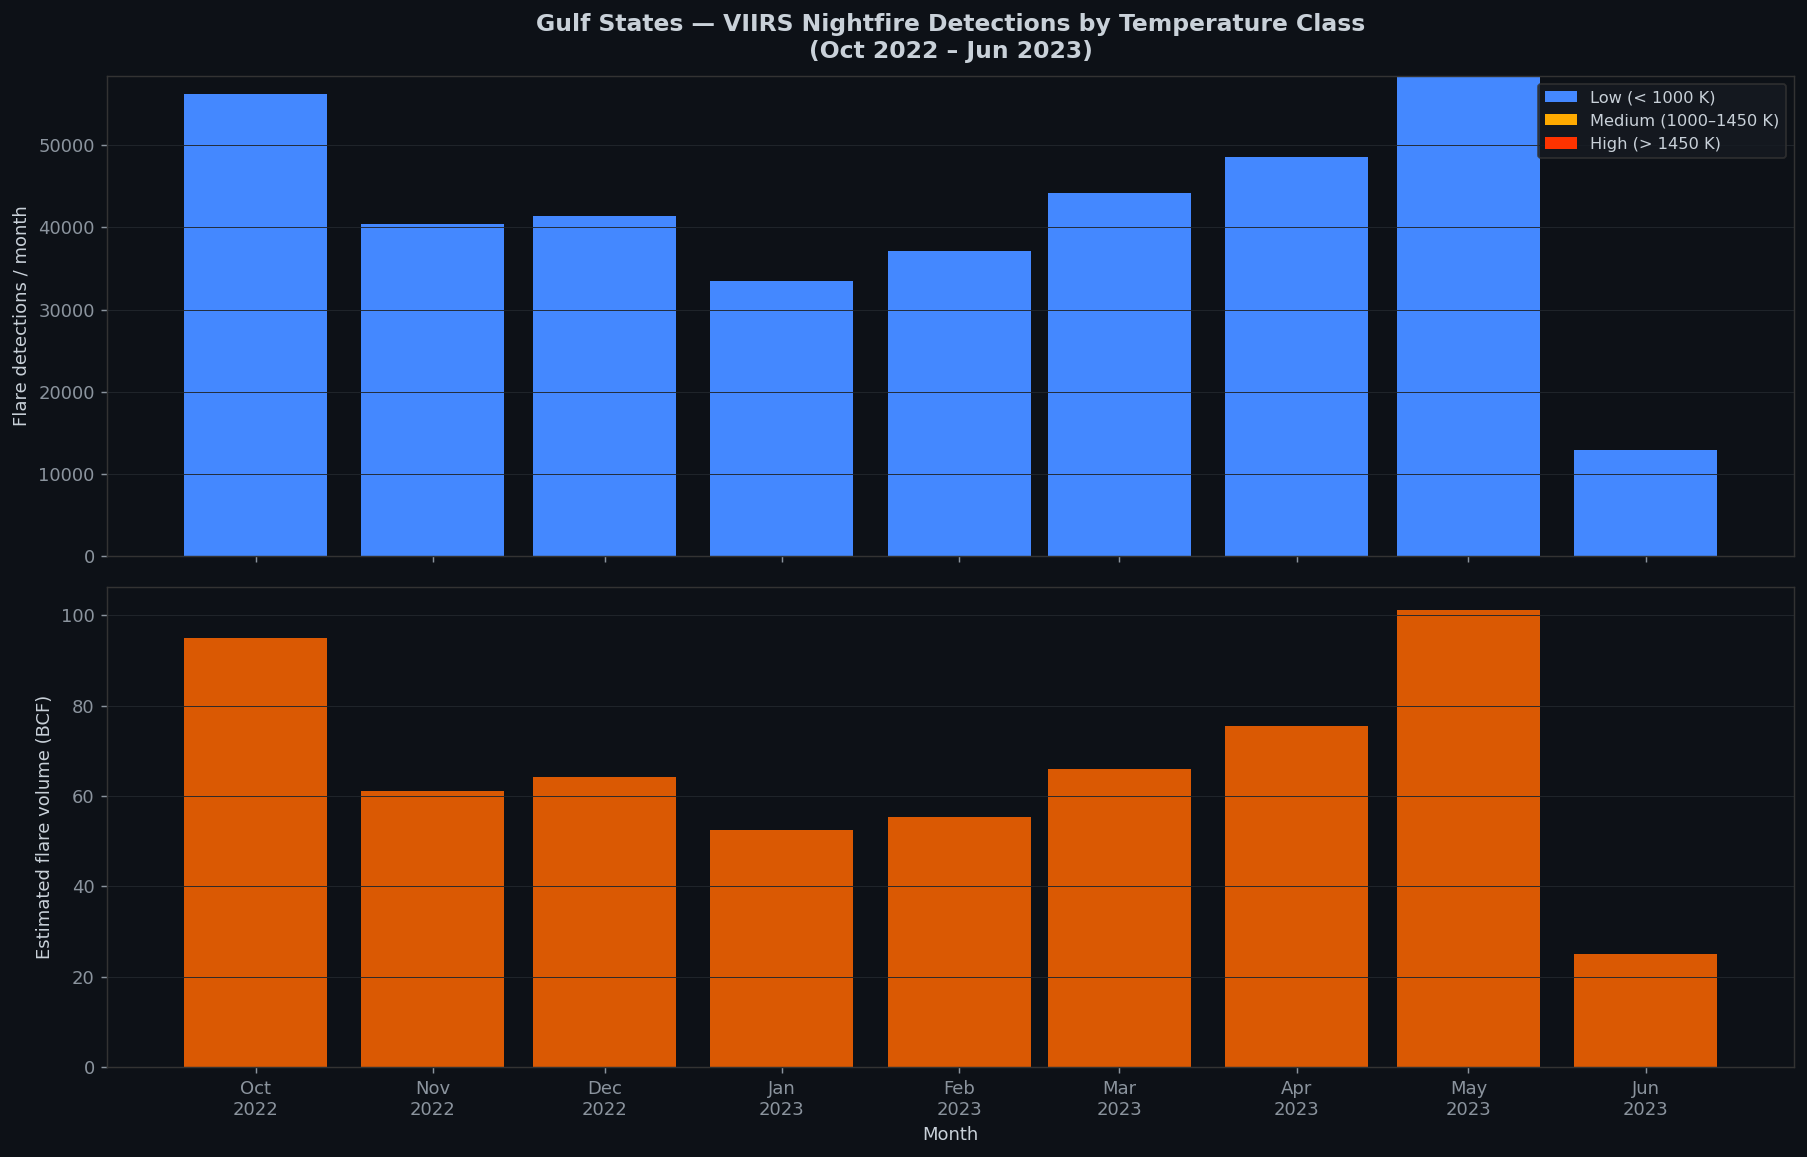

,total,low,medium,high,volume_bcf
month,,,,,
2022-10,56189,56189,0,0,94.968639
2022-11,40442,40442,0,0,61.077829
2022-12,41420,41420,0,0,64.141190
2023-01,33503,33503,0,0,52.500950
2023-02,37107,37107,0,0,55.376608
2023-03,44194,44194,0,0,65.979828
2023-04,48594,48594,0,0,75.441624
2023-05,58449,58449,0,0,101.198198
2023-06,12881,12881,0,0,25.133496


In [5]:
monthly = df.groupby("month").agg(
    total=("month", "size"),
    low=("Temp_class", lambda x: (x == "Low").sum()),
    medium=("Temp_class", lambda x: (x == "Medium").sum()),
    high=("Temp_class", lambda x: (x == "High").sum()),
    volume_bcf=("flare_volume_mcf", lambda x: x.sum() / 1e3),  # MCF -> BCF
).sort_index()

months = monthly.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: stacked bar — flare count by temp class ──
colors = {"Low": "#4488ff", "Medium": "#ffaa00", "High": "#ff3300"}
ax1.bar(months, monthly["low"],    color=colors["Low"],    label="Low (< 1000 K)", width=25)
ax1.bar(months, monthly["medium"], color=colors["Medium"], label="Medium (1000–1450 K)",
        bottom=monthly["low"], width=25)
ax1.bar(months, monthly["high"],   color=colors["High"],   label="High (> 1450 K)",
        bottom=monthly["low"] + monthly["medium"], width=25)
ax1.set_ylabel("Flare detections / month")
ax1.set_title("Gulf States — VIIRS Nightfire Detections by Temperature Class\n(Oct 2022 – Jun 2023)",
              fontsize=13, fontweight="bold", pad=10)
ax1.legend(loc="upper right", fontsize=9, facecolor="#161b22", edgecolor="#333")
ax1.grid(axis="y", color="#21262d", linewidth=0.5)

# ── Bottom: flare volume (BCF) ──
ax2.bar(months, monthly["volume_bcf"], color="#ff6600", width=25, alpha=0.85)
ax2.set_ylabel("Estimated flare volume (BCF)")
ax2.set_xlabel("Month")
ax2.grid(axis="y", color="#21262d", linewidth=0.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.savefig("data/timeseries_gulf_vnf.png", dpi=200, bbox_inches="tight")
plt.show()

monthly

## 5. Map — High temperature signatures (> 1450 K), 1–7 Jun 2023

High-temp detections 1-7 Jun 2023: 0


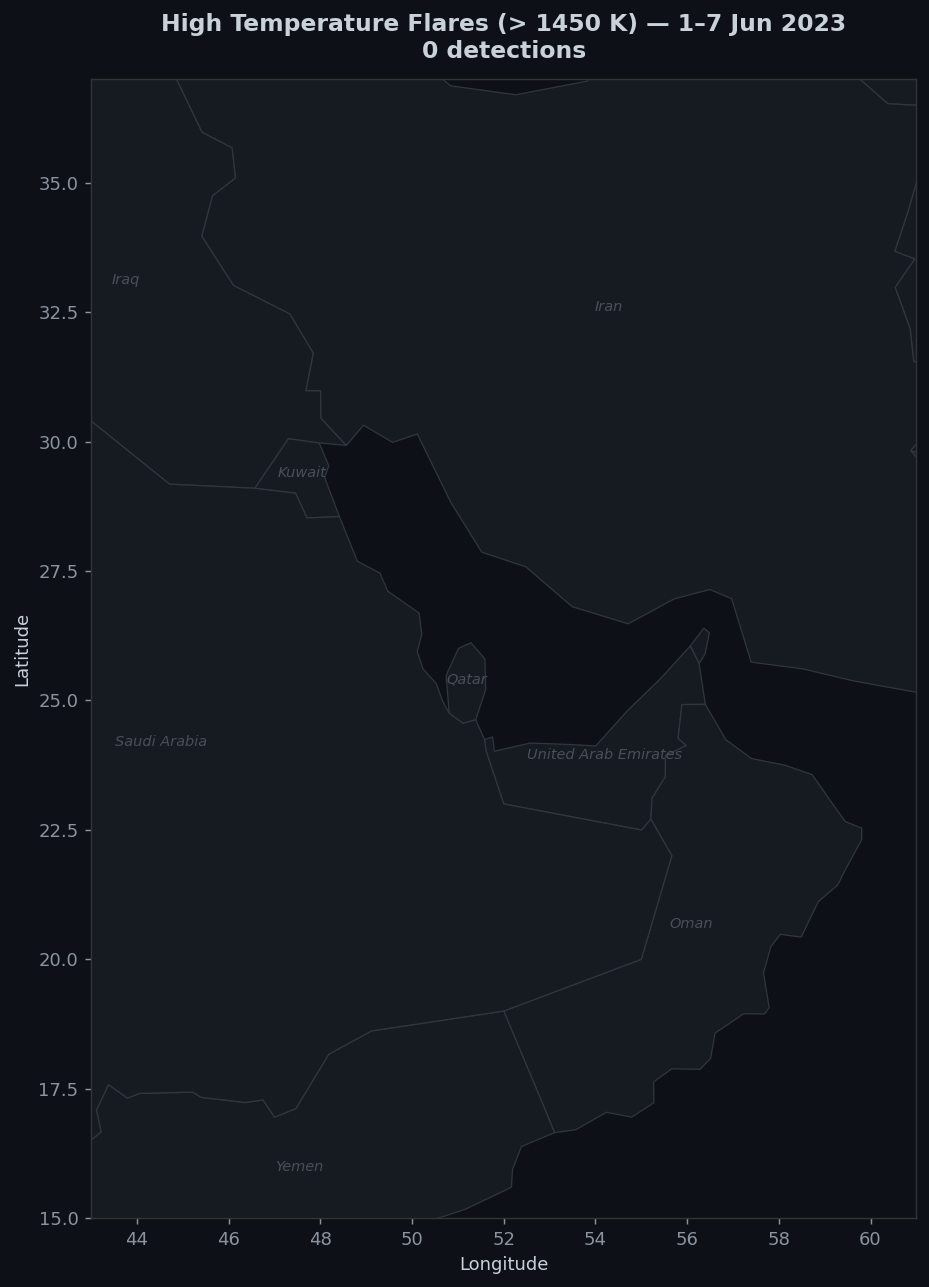

In [6]:
# Filter: high temp, 1-7 Jun 2023
hi = df[
    (df["Temp_class"] == "High") &
    (df["acq_date"] >= "2023-06-01") &
    (df["acq_date"] <= "2023-06-07")
].copy()
print(f"High-temp detections 1-7 Jun 2023: {len(hi)}")

# Load country borders
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
gulf = world.cx[43:61, 15:37]

fig, ax = plt.subplots(figsize=(14, 10))

gulf.plot(ax=ax, color="#161b22", edgecolor="#30363d", linewidth=0.7)

# Country labels
for _, row in gulf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    if 43 < cx < 61 and 15 < cy < 37:
        ax.text(cx, cy, row["NAME"], fontsize=8, color="#484f58", ha="center", style="italic")

# High-temp points
if not hi.empty:
    ax.scatter(
        hi["longitude"], hi["latitude"],
        c="#ff6600", s=hi["frp"].clip(lower=1) * 4, alpha=0.8,
        edgecolors="#ffcc00", linewidths=0.4, zorder=5,
    )

ax.set_xlim(43, 61)
ax.set_ylim(15, 37)
ax.set_title(f"High Temperature Flares (> 1450 K) — 1–7 Jun 2023\n{len(hi)} detections",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("data/map_high_temp_jun2023.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Save to GeoPackage

In [7]:
# Build final GeoDataFrame with VNF-compatible schema
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# Select VNF-equivalent columns for output
vnf_cols = [
    "latitude", "longitude", "acq_date", "acq_time", "satellite",
    "bright_ti4", "bright_ti5", "frp", "confidence", "scan", "track",
    "Temp_primary", "Area_primary", "RH_primary", "Temp_background",
    "Temp_class", "flare_volume_mcf", "country", "geometry",
]
gdf_out = gdf[[c for c in vnf_cols if c in gdf.columns]].copy()

# Convert period to string for GPKG compatibility
if "month" in gdf_out.columns:
    gdf_out["month"] = gdf_out["month"].astype(str)

gdf_out.to_file(GPKG_PATH, layer="flares_vnf", driver="GPKG")
print(f"Saved {len(gdf_out):,} records -> {GPKG_PATH}")
print(f"Columns: {list(gdf_out.columns)}")

Saved 372,779 records -> data\gulf_flares_vnf.gpkg
Columns: ['latitude', 'longitude', 'acq_date', 'acq_time', 'satellite', 'bright_ti4', 'bright_ti5', 'frp', 'confidence', 'scan', 'track', 'Temp_primary', 'Area_primary', 'RH_primary', 'Temp_background', 'Temp_class', 'flare_volume_mcf', 'country', 'geometry']
